# Power Spectral Density
A discrete Fourier transform allows us to examine how a finite signal record is distributed across frequency bins. For deterministic signals, the locations and shapes of spectral components are often predictable. For random signals, however, the spectral values vary from one realization to another.

In the previous notebook, we observed that:

* different realizations of the same random process produce different DFT values;
* one finite record of white noise does not produce a perfectly flat spectrum;
* increasing the record length gives finer frequency spacing but does not remove random spectral variability;
* a single DFT is therefore not a stable description of a random process.

Before addressing how to obtain a more stable spectral estimate, we must resolve another important problem:

> How should spectral power be represented so that results obtained using different record lengths can be meaningfully compared?

This notebook introduces **power spectral density**, or **PSD**, as the answer to this question.

## Learning Outcomes
After completing this notebook, you should be able to:

1. explain why power per DFT bin depends on frequency-bin width;
2. explain the meaning and units of power spectral density;
3. calculate correctly normalized two-sided and one-sided PSDs;
4. apply window-energy correction to a PSD calculation;
5. verify that integrating a PSD reproduces an appropriate time-domain mean-square value;
6. interpret broadband noise and tonal components in a PSD;
7. convert a PSD from linear units to decibels correctly.

## 1. Why Power per DFT Bin Is Not Enough
### 1.1 Frequency bins represent frequency intervals
Consider a sampled signal containing ($N$) samples, acquired using a sampling frequency ($f_s$).

The frequency spacing of its DFT is
\\[
\Delta f=\frac{f_s}{N}.
\\]

Each DFT bin therefore represents a frequency interval of width ($\Delta f$).

If the sampling frequency remains constant and the record length increases, then:
* the number of DFT bins increases;
* the frequency spacing becomes smaller;
* each bin represents a narrower frequency interval.

For example, consider two records sampled at
\\[
f_s=1000\ \text{Hz}.
\\]

If the first record contains (N=1000) samples,
\\[
\Delta f=\frac{1000}{1000}=1\ \text{Hz}.
\\]

If the second record contains (N=4000) samples,
\\[
\Delta f=\frac{1000}{4000}=0.25\ \text{Hz}.
\\]

The second DFT divides the same frequency range into bins that are four times narrower.

### 1.2 Observation: white-noise power per bin changes with record length
Suppose that two records are generated from the same zero-mean white-noise process. Both records have the same variance and are sampled at the same sampling frequency, but they have different lengths.

Because the records are generated by the same process, we expect them to represent approximately the same total mean-square signal power.

However, the longer record has narrower frequency bins. The total noise power is therefore distributed across a larger number of bins.

Let us observe this numerically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Use a fixed random-number generator seed so that the experiment can be reproduced.
random_generator = np.random.default_rng(10)

fs = 1000
short_length = 1000
long_length = 4000

short_noise = random_generator.normal(0, 1, short_length)
long_noise = random_generator.normal(0, 1, long_length)

short_df = fs / short_length
long_df = fs / long_length

print(f"Short-record frequency spacing: {short_df:.2f} Hz")
print(f"Long-record frequency spacing: {long_df:.2f} Hz")

Short-record frequency spacing: 1.00 Hz
Long-record frequency spacing: 0.25 Hz


For NumPy's unnormalized forward DFT,
\\[
X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}.
\\]

Parseval's theorem gives
\\[
\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2 = \frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2.
\\]

Therefore, the two-sided mean-square power associated with DFT bin $k$ is
\\[
P_{\text{bin}}[k]=\frac{|X[k]|^2}{N^2}.
\\]

In [2]:
# Calculate the DFTs and the two-sided power per bin.
short_dft = np.fft.fft(short_noise)
long_dft = np.fft.fft(long_noise)

short_power_per_bin = np.abs(short_dft) ** 2 / short_length ** 2
long_power_per_bin = np.abs(long_dft) ** 2 / long_length ** 2

short_power_per_bin_one_sided = short_power_per_bin[:short_length // 2 + 1].copy()
long_power_per_bin_one_sided = long_power_per_bin[:long_length // 2 + 1].copy()

short_power_per_bin_one_sided[1:-1] *= 2
long_power_per_bin_one_sided[1:-1] *= 2

short_frequency = np.fft.rfftfreq(short_length, 1 / fs)
long_frequency = np.fft.rfftfreq(long_length, 1 / fs)

In [3]:
fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(short_frequency, short_power_per_bin_one_sided, 
        label=f"N = {short_length}, df = {short_df:.2f} Hz")
ax.plot(long_frequency, long_power_per_bin_one_sided, 
        label=f"N = {long_length}, df = {long_df:.2f} Hz", alpha=0.7)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power per DFT bin")
ax.set_title("White-Noise Power per DFT Bin")
ax.grid()
ax.legend()
plt.close(fig)

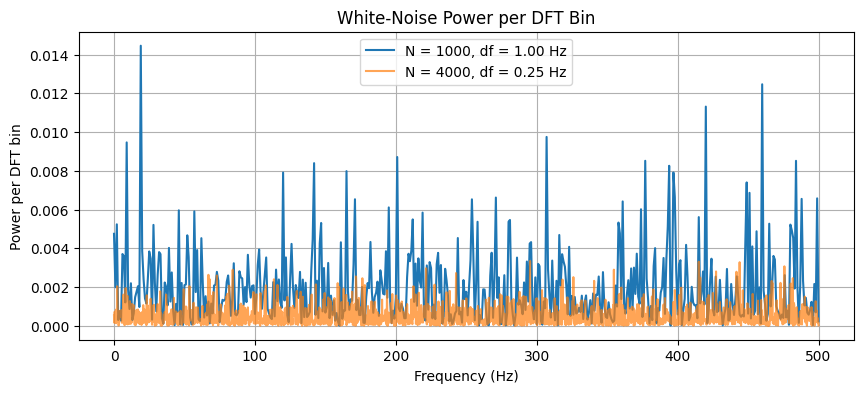

In [4]:
display(fig)

#### Irregularities
The individual spectral values are irregular because the two records are different random realizations. Nevertheless, there should also be a systematic difference between their typical power-per-bin levels.

In [5]:
# Calculate the mean power per bin over 
# a selected frequency range away from DC and Nyquist.
comparison_frequency_minimum = 100
comparison_frequency_maximum = 400

short_comparison_bins = (short_frequency >= comparison_frequency_minimum) & (short_frequency <= comparison_frequency_maximum)
long_comparison_bins = (long_frequency >= comparison_frequency_minimum) & (long_frequency <= comparison_frequency_maximum)

short_mean_power_per_bin = np.mean(short_power_per_bin_one_sided[short_comparison_bins])
long_mean_power_per_bin = np.mean(long_power_per_bin_one_sided[long_comparison_bins])

print(f"Mean short-record power per bin: {short_mean_power_per_bin:.6f}")
print(f"Mean long-record power per bin:  {long_mean_power_per_bin:.6f}")
print(f"Ratio: {short_mean_power_per_bin / long_mean_power_per_bin:.2f}")

Mean short-record power per bin: 0.001937
Mean long-record power per bin:  0.000493
Ratio: 3.93


Because the long-record bins are four times narrower, their typical power per bin should also be approximately four times smaller.

> Why is the ratio not exactly four times?

### 1.3 The average power over the record has not disappeared
A smaller power-per-bin value does not mean that the longer record contains less total noise power.
* The longer record contains more frequency bins, and
* each bin represents a narrower frequency interval.

Verify the total power by summing all one-sided power-bin values.

In [6]:
short_frequency_domain_power = np.sum(short_power_per_bin_one_sided)
long_frequency_domain_power = np.sum(long_power_per_bin_one_sided)

# Compare these values with the time-domain mean-square values.
short_time_domain_power = np.mean(short_noise ** 2)
long_time_domain_power = np.mean(long_noise ** 2)

print(f"Short-record time-domain mean square: {short_time_domain_power:.6f}")
print(f"Short-record summed bin power:         {short_frequency_domain_power:.6f}")

print(f"Long-record time-domain mean square:  {long_time_domain_power:.6f}")
print(f"Long-record summed bin power:          {long_frequency_domain_power:.6f}")

Short-record time-domain mean square: 0.993860
Short-record summed bin power:         0.993860
Long-record time-domain mean square:  0.988830
Long-record summed bin power:          0.988830


#### Average power over the record
Apart from numerical roundoff, each summed frequency-domain result should equal the corresponding time-domain mean-square value.

The two records should also have approximately the same average power because both were generated from a unit-variance white-noise process.

Therefore:
* average power remains approximately unchanged;
* narrower bins contain less power individually;
* more bins are required to cover the same frequency range.

### 1.4 Question: can power per bin be compared directly?
The two DFT calculations describe signals generated from the same random process. Nevertheless, their typical power-per-bin values are different because their bin widths are different.

This means that the statement

> “This bin contains a power of (0.002)”

is **incomplete** when spectra with different frequency resolutions are being compared.

We must also know how much frequency bandwidth the bin represents.

> A bin containing a certain amount of power over $1\ \text{Hz}$ is not directly comparable with a bin containing power over $0.25\ \text{Hz}$.

The relevant quantities are:
* power in the bin
* bandwidth represented by the bin.

This suggests that we should normalize the power by the corresponding frequency bandwidth.

### 1.5 Toward a spectral power density
For a frequency bin of width $\Delta f$, consider the ratio
\\[
\frac{\text{power in the bin}}{\text{bin width}}.
\\]

Its units are
\\[
\frac{\text{signal unit}^2}{\text{Hz}}.
\\]

For example, if ($x[n]$) represents voltage, then:
* mean-square voltage has units of $\mathrm{V^2}$;
* power per DFT bin has units of $\mathrm{V^2}$;
* power divided by frequency bandwidth has units of $\mathrm{V^2/Hz}$.

A quantity expressed per unit frequency is called a **spectral density**.

In the next section, we will define the **power spectral density** as
\\[
\text{PSD} \approx \frac{\text{power in a frequency interval}}{\text{width of that frequency interval}}.
\\]

Equivalently,
\\[
\text{power in a frequency interval}\approx\text{PSD}\times\text{bandwidth}.
\\]

This normalization will allow spectra calculated using different record lengths and different frequency-bin widths to be placed on a comparable scale.

#### Takeaway
> Power per DFT bin depends on the bin width ($\Delta f$).

A longer record produces narrower frequency bins. For broadband noise, each narrower bin contains less power even though the total mean-square signal power remains approximately unchanged.

Therefore, power per bin cannot be compared directly when the frequency resolutions are different. A bandwidth-normalized quantity is needed.

## 2. From Power per Bin to Power Spectral Density
In the previous section, we observed that the power contained in each DFT bin depends on the frequency-bin width.

For broadband noise:
* a longer record produces narrower frequency bins;
* narrower bins contain less power individually;
* the total mean-square signal (average power) remains approximately unchanged.

Therefore, power per DFT bin cannot be compared directly when two spectra have different frequency resolutions.

**We now introduce a quantity that removes this dependence on bin width**.

### 2.1 From an amount to a density
A **density** describes how much of a quantity is contained per unit interval.

For example:
* mass density describes mass per unit volume;
* probability density describes probability per unit variable;
* power spectral density describes mean-square signal power per unit frequency.

Suppose a frequency bin contains power $P_{\text{bin}}[k]$ and represents a frequency interval of width $\Delta f$.

The power per unit frequency is then
\\[
\\S_{xx}[k] = \frac{P_{\text{bin}}[k]}{\Delta f}.
\\]

> The quantity $S_{xx}[k]$ is a **power spectral density**, or PSD.

Rearranging the relationship gives
\\[
P_{\text{bin}}[k] = S_{xx}[k]\Delta f.
\\]

This equation provides the most useful interpretation of PSD:
> PSD tells us how much mean-square signal (average power) is present per hertz.

For a sufficiently narrow frequency interval,
\\[
\text{power in the interval} \approx \text{PSD}\times\text{bandwidth}.
\\]

PSD is therefore not the power contained in one DFT bin. It is the power normalized by the frequency bandwidth represented by that bin.

### 2.2 Units of power spectral density
Suppose $x[n]$ represents a voltage signal measured in volts.

The corresponding quantities have the following units:
| Quantity                          | Units             |
| --------------------------------- | ----------------- |
| Signal amplitude $x[n]$           | $\mathrm{V}$      |
| Squared signal amplitude $x^2[n]$ | $\mathrm{V^2}$    |
| Mean-square signal power          | $\mathrm{V^2}$    |
| Power in a DFT bin                | $\mathrm{V^2}$    |
| Power spectral density            | $\mathrm{V^2/Hz}$ |

If the signal is dimensionless, PSD has units of $\text{unit}^2/\text{Hz}$.

For an acoustic-pressure signal measured in pascals, PSD has units of $\mathrm{Pa^2/Hz}$.

The unit “per hertz” is essential. It distinguishes PSD from power per DFT bin.

### 2.3 Calculating PSD from the previous experiment
In the previous section, we calculated the one-sided power per DFT bin for two white-noise records:
* `short_power_per_bin_one_sided`;
* `long_power_per_bin_one_sided`.

The records have different frequency-bin spacings:
* `short_df`;
* `long_df`.

Let's calculate the PSD by dividing the power in each bin by its corresponding bin width. The resulting arrays have units of signal unit squared per hertz. We can plot both PSD estimates on the same axes.

In [7]:
short_psd = short_power_per_bin_one_sided / short_df
long_psd = long_power_per_bin_one_sided / long_df

fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(short_frequency, short_psd, label=f"N = {short_length}, Δf = {short_df:.2f} Hz")
ax.plot(long_frequency, long_psd, label=f"N = {long_length}, Δf = {long_df:.2f} Hz", alpha=0.7)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (unit²/Hz)")
ax.set_title("White-Noise Power Spectral Density")
ax.grid()
ax.legend()
plt.close(fig)

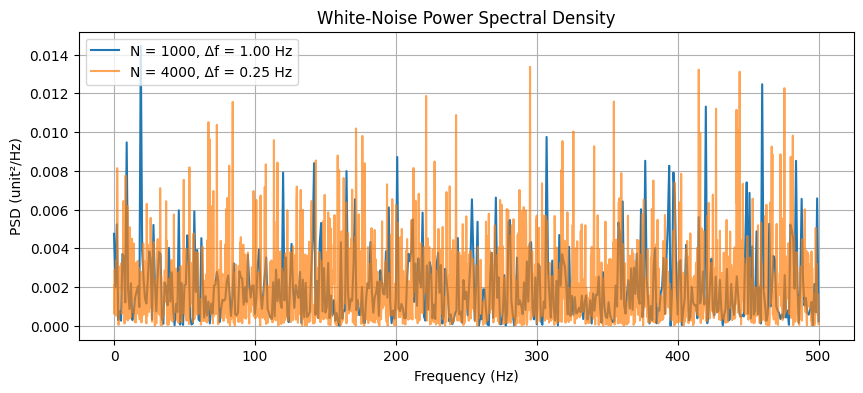

In [8]:
display(fig)

The individual PSD values remain irregular because each record is one finite realization of a random process. **However, the typical PSD levels should now be approximately comparable**.

This is different from the power-per-bin plot in the previous section, where the longer record had a systematically lower level.

### 2.4 Comparing the typical PSD levels
Calculate the mean PSD over the same frequency range used previously.

In [9]:
short_mean_psd = np.mean(short_psd[short_comparison_bins])
long_mean_psd = np.mean(long_psd[long_comparison_bins])

print(f"Mean short-record PSD: {short_mean_psd:.6f} unit²/Hz")
print(f"Mean long-record PSD:  {long_mean_psd:.6f} unit²/Hz")
print(f"Ratio: {short_mean_psd / long_mean_psd:.2f}")

Mean short-record PSD: 0.001937 unit²/Hz
Mean long-record PSD:  0.001972 unit²/Hz
Ratio: 0.98


#### PSD of the unit variance white noise
The two values will not be identical because the records are finite and random. Nevertheless, their ratio should be much closer to one than the ratio of their mean power-per-bin values.

For ideal white noise, the average power is distributed uniformly over frequency.

Let its mean-square value be approximately
\\[
\sigma^2.
\\]

The one-sided frequency range extends from DC to the Nyquist frequency and therefore has a total bandwidth of
\\[
\frac{f_s}{2}.
\\]

If the theoretical one-sided PSD level is constant and equal to (S_0), its integrated power is
\\[
S_0\frac{f_s}{2}.
\\]

This integrated power must equal the signal mean-square value (see Parseval's theorem):
\\[
S_0\frac{f_s}{2} = \sigma^2.
\\]

Therefore,
\\[
S_0 = \frac{2\sigma^2}{f_s}.
\\]

The noise records in this experiment were generated with a standard deviation of (1), so their mean-square values are approximately
\\[
\sigma^2=1.
\\]

the theoretical one-sided PSD level for $f_{s}=1000\$ Hz is therefore
\\[
S_0 = \frac{2}{1000} = 0.002\ \text{unit}^2/\text{Hz}.
\\]

The factor of two appears because this is a one-sided representation of a real-valued signal. The detailed one-sided normalization will be developed later. 

A finite noise record will not produce exactly this value in every frequency bin. Its PSD values fluctuate around the theoretical level.

In [10]:
# Compare the numerical values with this expected level.

expected_one_sided_psd = 2 / fs

print(f"Expected one-sided PSD: {expected_one_sided_psd:.6f} unit²/Hz")
print(f"Mean short-record PSD:  {short_mean_psd:.6f} unit²/Hz")
print(f"Mean long-record PSD:   {long_mean_psd:.6f} unit²/Hz")

Expected one-sided PSD: 0.002000 unit²/Hz
Mean short-record PSD:  0.001937 unit²/Hz
Mean long-record PSD:   0.001972 unit²/Hz


**The finite-record PSDs fluctuate around the expected level rather than forming perfectly horizontal lines**.

### 2.5 Power in a frequency interval
PSD is useful because it allows power to be calculated over a specified frequency interval.

For a single DFT bin,
\\[
    P_{\text{bin}}[k] = S_{xx}[k]\Delta f.
\\]

For several adjacent frequency bins,
\\[
    P_{\text{band}} \approx \sum_{k\in\text{band}}S_{xx}[k]\Delta f.
\\]

This is a numerical approximation to the continuous-frequency relationship
\\[
P_{\text{band}} = \int_{f_1}^{f_2}S_{xx}(f)df.
\\]

The area under a PSD curve therefore represents mean-square signal (average power).

#### Power comparsison
Consider the frequency interval from 100 Hz to 400 Hz. Calculate the power in this interval using the short-record PSD, and compare it to that of the long-record PSD.

In [11]:
short_band_power = np.sum(short_psd[short_comparison_bins]) * short_df
long_band_power = np.sum(long_psd[long_comparison_bins]) * long_df

print(f"Short-record power from 100 Hz to 400 Hz: {short_band_power:.6f}")
print(f"Long-record power from 100 Hz to 400 Hz:  {long_band_power:.6f}")

Short-record power from 100 Hz to 400 Hz: 0.583154
Long-record power from 100 Hz to 400 Hz:  0.591984


The two values should be approximately similar because both records represent the same white-noise process and the same frequency bandwidth.

They will not be exactly equal because the records are different random realizations.

### 2.6 Why the bandwidth factor must be included
It is incorrect to estimate band power by adding PSD values alone:
\\[
\sum_{k\in\text{band}}S_{xx}[k].
\\]

Each PSD value has units of
\\[
\text{unit}^2/\text{Hz}.
\\]

Adding such values does not remove the “per hertz” part of the units.

The PSD must be multiplied by the frequency increment:
\\[
P_{\text{band}} \approx \sum_{k\in\text{band}}S_{xx}[k]\Delta f.
\\]

The units then become
\\[
\frac{\text{unit}^2}{\text{Hz}}\times\text{Hz} = \text{unit}^2.
\\]

This is the correct unit for mean-square signal (average power).

The distinction is especially important when comparing DFTs with different record lengths. The longer record contains more PSD samples within the same frequency interval, but each sample represents a smaller bandwidth.

### 2.7 Integrating over the complete one-sided frequency range
The complete one-sided PSD covers frequencies from DC to the Nyquist frequency. This is sum of the PSD over the complete frequency range and multiply by the bin width.

In [12]:
short_integrated_psd = np.sum(short_psd) * short_df
long_integrated_psd = np.sum(long_psd) * long_df

# Compare the results with the corresponding time-domain mean-square values.
print(f"Short-record time-domain mean square: {short_time_domain_power:.6f}")
print(f"Short-record integrated PSD:          {short_integrated_psd:.6f}")

print(f"Long-record time-domain mean square:  {long_time_domain_power:.6f}")
print(f"Long-record integrated PSD:           {long_integrated_psd:.6f}")

Short-record time-domain mean square: 0.993860
Short-record integrated PSD:          0.993860
Long-record time-domain mean square:  0.988830
Long-record integrated PSD:           0.988830


Apart from numerical roundoff, the integrated PSD should reproduce the time-domain mean-square value.

This result is not a coincidence. The PSD normalization is chosen specifically so that
\\[
\sum_k S_{xx}[k]\Delta f = \text{mean-square signal power}.
\\]

The exact normalization will be derived from Parseval’s theorem in the next section.

### 2.8 What PSD normalization solves
Dividing power per bin by $\Delta f$ solves an important comparison problem.

When record length changes:
* $\Delta f$ changes;
* power per bin changes;
* the number of bins in a frequency interval changes;
* PSD remains on an approximately comparable power-per-hertz scale.

However, PSD normalization does **not** eliminate random spectral variability. A single finite-record PSD estimate of white noise is still irregular.

The following two problems must therefore be kept separate:
1. **Normalization problem:**
   How should spectral power be expressed so that different frequency resolutions can be compared?
2. **Estimation problem:**
   How can random spectral variability be reduced to obtain a more stable description?

This notebook addresses the first problem. A later notebook on PSD estimation and averaging will address the second.

#### Review questions
1. Why does the typical power per DFT bin decrease when the record length increases?
2. Why does dividing power per bin by $\Delta f$ make spectra with different record lengths more comparable?
3. What are the units of PSD if the original signal is measured in volts?
4. Why must PSD be multiplied by bandwidth when calculating power in a frequency interval?
5. Does PSD normalization make one white-noise realization produce a flat spectral curve?
6. Two records have the same sampling frequency, but one record is twice as long as the other. How do their values of $\Delta f$ compare?
7. If a PSD is approximately constant at
\\[
0.004\ \mathrm{V^2/Hz},
\\]
what mean-square voltage is contained in a $20\ \text{Hz}$ frequency interval?

#### Takeaway
> Power spectral density is mean-square signal power per unit frequency.

For a DFT bin of width $\Delta f$,
\\[
S_{xx}[k] = \frac{P_{\text{bin}}[k]}{\Delta f},
\\]

and
\\[
P_{\text{bin}}[k] = S_{xx}[k]\Delta f.
\\]

For a wider frequency interval,
\\[
\text{power in the interval} \approx \sum S_{xx}[k]\Delta f.
\\]

PSD normalization makes broadband spectral levels approximately comparable when record lengths and frequency-bin widths differ. It does not, by itself, remove the random variability of a finite-record spectral estimate.

## 3. Deriving the Two-Sided PSD
In the previous section, we introduced power spectral density through the relationship
\\[
S_{xx}[k] = \frac{P_{\text{bin}}[k]}{\Delta f}.
\\]

We now derive the complete two-sided PSD normalization from the DFT convention and Parseval’s theorem.

The goal is to obtain a PSD whose frequency-domain sum satisfies

\\[
\sum_k S_{xx}[k]\Delta f = \text{time-domain mean-square value}.
\\]

This section considers an unwindowed finite record. Window normalization will be introduced in the next section.

### 3.1 Start from the DFT convention
NumPy uses an unnormalized forward DFT:
\\[
X[k] = \sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}.
\\]

The corresponding inverse DFT is
\\[
x[n] = \frac{1}{N}\sum_{k=0}^{N-1}X[k]e^{j2\pi kn/N}.
\\]

Because the factor $1/N$ appears only in the inverse transform, the squared DFT magnitude $|X[k]|^2$ is not directly equal to signal power.

**The normalization must be derived from Parseval’s theorem**.

### 3.2 Parseval’s theorem and mean-square value
For the DFT convention above, Parseval’s theorem states that
\\[
\sum_{n=0}^{N-1}|x[n]|^2 = \frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2.
\\]

Divide both sides by $N$:
\\[
\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2 = \frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2.
\\]

The left-hand side is the mean-square value of the finite record:
\\[
P_{\text{avg}} = \frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2.
\\]

Therefore,
\\[
P_{\text{avg}} = \sum_{k=0}^{N-1}\frac{|X[k]|^2}{N^2}.
\\]

This suggests defining the two-sided power in DFT bin (k) as
\\[
P_{\text{bin}}^{(2)}[k] = \frac{|X[k]|^2}{N^2}.
\\]

The superscript $(2)$ indicates that the power is distributed over both positive and negative frequencies.

Summing all two-sided bin powers gives

\\[
\sum_{k=0}^{N-1}P_{\text{bin}}^{(2)}[k] = P_{\text{avg}}.
\\]

### 3.3 Divide bin power by frequency-bin width
The DFT frequency spacing is
\\[
\Delta f = \frac{f_s}{N}.
\\]

Power spectral density is power per unit frequency:
\\[
S_{xx}^{(2)}[k] = \frac{P_{\text{bin}}^{(2)}[k]}{\Delta f}.
\\]

Substitute $P_{\text{bin}}^{(2)}[k] = \frac{|X[k]|^2}{N^2}$ and $\Delta f = \frac{f_s}{N}$. Then
\\[
S_{xx}^{(2)}[k] = \frac{|X[k]|^2/N^2}{f_s/N}.
\\]

Simplifying gives
\\[
\boxed{S_{xx}^{(2)}[k] = \frac{|X[k]|^2}{Nf_s}}
\\]

This is the two-sided PSD of an unwindowed finite record using NumPy’s DFT convention.

### 3.4 Why the denominator is $Nf_s$
The denominator contains two factors with different purposes:
\\[
S_{xx}^{(2)}[k] = \frac{|X[k]|^2}{Nf_s}.
\\]

* The factor $N$ is required by the DFT energy normalization.
* The factor $f_s$ converts the result from power per bin to power per hertz.

The same formula can be viewed as two consecutive steps:
\\[
|X[k]|^2\quad\longrightarrow\quad\frac{|X[k]|^2}{N^2}\quad\longrightarrow\quad\frac{|X[k]|^2}{N^2}\frac{N}{f_s}.
\\]

Therefore,
\\[
\text{squared DFT magnitude}\neq\text{power per bin}\neq\text{PSD}.
\\]

These quantities should not be used interchangeably.

### 3.5 Verifying the integrated PSD relationship
From the PSD definition,
\\[
S_{xx}^{(2)}[k]\Delta f = P_{\text{bin}}^{(2)}[k].
\\]

Therefore,
\\[
\sum_{k=0}^{N-1}S_{xx}^{(2)}[k]\Delta f = \sum_{k=0}^{N-1}P_{\text{bin}}^{(2)}[k].
\\]

Parseval’s theorem then gives
\\[
\boxed{\sum_{k=0}^{N-1}S_{xx}^{(2)}[k]\Delta f = \frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2}
\\]

\\[
\boxed{\sum_{k=0}^{N-1}S_{xx}^{(2)}[k]\Delta f = \frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2}
\\]

The left-hand side is the area represented by all PSD bins. The right-hand side is the time-domain mean-square value.

Each PSD bin can therefore be viewed as a rectangle with:
* height $S_{xx}^{(2)}[k]$;
* width $\Delta f$;
* area $S_{xx}^{(2)}[k]\Delta f$.

The area of one rectangle is the power in one DFT bin. The total area is the mean-square power of the record.

### 3.6 Numerical verification with a finite record
Use the short white-noise record from the previous sections.

In [13]:
record = short_noise
record_length = len(record)
df = fs / record_length

dft_values = np.fft.fft(record)
psd_two_sided = np.abs(dft_values) ** 2 / (record_length * fs)
frequency_two_sided = np.fft.fftfreq(record_length, 1 / fs)

time_domain_mean_square = np.mean(np.abs(record) ** 2)

integrated_two_sided_psd = np.sum(psd_two_sided) * df

print(f"Time-domain mean square: {time_domain_mean_square:.12f}")
print(f"Integrated two-sided PSD: {integrated_two_sided_psd:.12f}")

Time-domain mean square: 0.993860022067
Integrated two-sided PSD: 0.993860022067


Apart from floating-point roundoff, the values should be equal. This verification is exact for the finite record because it follows directly from Parseval’s theorem.

### 3.7 Plotting the two-sided PSD
The frequency array produced by `np.fft.fftfreq()` is ordered as
\\[
0,\ \text{positive frequencies},\ \text{negative frequencies}.
\\]

For visualization, use `np.fft.fftshift()` to arrange the frequencies from negative to positive.
\\[
\text{negative frequencies},\ 0,\ \text{positive frequencies}.
\\]

In [14]:
frequency_two_sided_shifted = np.fft.fftshift(frequency_two_sided)
psd_two_sided_shifted = np.fft.fftshift(psd_two_sided)

fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(frequency_two_sided_shifted, psd_two_sided_shifted)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Two-sided PSD (unit²/Hz)")
ax.set_title("Two-Sided PSD of a Finite White-Noise Record")
ax.grid()
plt.close(fig)

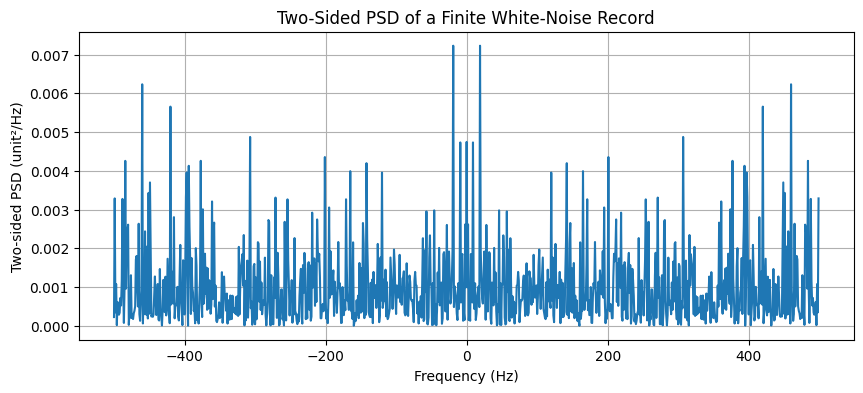

In [15]:
display(fig)

For a real-valued signal, the two-sided PSD is symmetric:
\\[
S_{xx}^{(2)}[-f] = S_{xx}^{(2)}[f].
\\]

The values at corresponding positive and negative frequencies represent matching contributions to the total signal power.

The plotted PSD remains irregular because it was calculated from one finite noise record. Correct normalization does not remove random spectral variability.

### 3.8 A compact derivation
The complete derivation can be summarized as follows.

Start with Parseval’s theorem:
\\[
\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2 = \frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2.
\\]

Define two-sided power per DFT bin:
\\[
P_{\text{bin}}^{(2)}[k] = \frac{|X[k]|^2}{N^2}.
\\]

Divide by the bin width:
\\[
S_{xx}^{(2)}[k] = \frac{P_{\text{bin}}^{(2)}[k]}{\Delta f}.
\\]

Use $\Delta f=\frac{f_s}{N}$. Then
\\[
\boxed{S_{xx}^{(2)}[k] = \frac{|X[k]|^2}{Nf_s}}
\\]

and
\\[
\boxed{\sum_{k=0}^{N-1}S_{xx}^{(2)}[k]\Delta f = \frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2}
\\]

#### Terminology note
The array
\\[
\frac{|X[k]|^2}{Nf_s}
\\]
calculated from one finite record is more precisely called a **finite-record PSD estimate**.

It is also commonly called a **periodogram**.

In this notebook, we will use the term PSD estimate when referring to the quantity calculated from a finite record. The statistical properties of the periodogram will be postponed to the later notebook on PSD estimation and averaging.

#### Review questions
1. Why is $|X[k]|^2$ not yet a PSD?
2. What factor converts squared DFT magnitude into power per DFT bin?
3. What factor converts power per bin into power per hertz?
4. For NumPy’s DFT convention, why does the two-sided PSD denominator contain $Nf_s$?
5. What does $S_{xx}^{(2)}[k]\Delta f$ represent?
6. What should be obtained when the complete two-sided PSD is summed and multiplied by $\Delta f$?
7. If the signal is measured in pascals, what are the units of its PSD?
8. Does correct PSD normalization make a finite white-noise PSD smooth?

#### Takeaway
For NumPy’s unnormalized forward DFT,
\\[
X[k] = \sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N},
\\]

the two-sided PSD of an unwindowed finite record is
\\[
\boxed{S_{xx}^{(2)}[k] = \frac{|X[k]|^2}{Nf_s}}
\\]

The normalization is chosen so that
\\[
\boxed{\sum_k S_{xx}^{(2)}[k]\Delta f = \frac{1}{N}\sum_n |x[n]|^2}
\\]

Therefore, the area represented by the complete PSD equals the time-domain mean-square value of the record.

## 4. PSD of a Windowed Record
The two-sided PSD derived in the previous section was

\\[
S_{xx}^{(2)}[k] = \frac{|X[k]|^2}{Nf_s}.
\\]

This formula assumes that the finite record is used directly, which is equivalent to applying a rectangular window.

> In practical spectral analysis, we often apply a window such as a Hann window to reduce spectral leakage. However, multiplying a signal by a window changes its mean-square value.

The PSD normalization must therefore account for the energy of the window.

### 4.1 A window changes the record
Let the original finite record be $x[n],\ 0\le n<N$.

After applying a window $w[n]$, the analyzed record becomes
\\[
x_w[n] = x[n]w[n].
\\]

Its DFT is
\\[
X_w[k] = \sum_{n=0}^{N-1}x[n]w[n]e^{-j2\pi kn/N}.
\\]
Because most nonrectangular windows reduce the samples near the ends of the record, the windowed signal generally has a smaller mean-square value than the original signal.

Let us observe this effect.

In [16]:
# Use the short noise record from the previous sections.
record = short_noise
record_length = len(record)

rectangular_window = np.ones(record_length)
hann_window = np.hanning(record_length)

record_rectangular = record * rectangular_window
record_hann = record * hann_window

original_mean_square = np.mean(record ** 2)
rectangular_mean_square = np.mean(record_rectangular ** 2)
hann_mean_square = np.mean(record_hann ** 2)

print(f"Original mean square:            {original_mean_square:.6f}")
print(f"Rectangular-window mean square:  {rectangular_mean_square:.6f}")
print(f"Hann-window mean square:         {hann_mean_square:.6f}")

Original mean square:            0.993860
Rectangular-window mean square:  0.993860
Hann-window mean square:         0.381217


### 4.2 Applying the unwindowed PSD formula directly
Suppose we apply the formula from the previous section directly to the windowed DFT:
\\[
\widetilde{S}_{xx,w}^{(2)}[k] = \frac{|X_w[k]|^2}{Nf_s}.
\\]

Calculate the DFTs of the two windowed records.

In [17]:
rectangular_dft = np.fft.fft(record_rectangular)
hann_dft = np.fft.fft(record_hann)

rectangular_psd_uncorrected = np.abs(rectangular_dft) ** 2 / (record_length * fs)
hann_psd_uncorrected = np.abs(hann_dft) ** 2 / (record_length * fs)

#Integrate the two PSDs over frequency.
df = fs / record_length
rectangular_integrated_uncorrected = np.sum(rectangular_psd_uncorrected) * df
hann_integrated_uncorrected = np.sum(hann_psd_uncorrected) * df

print(f"Rectangular-window mean square:  {rectangular_mean_square:.6f}")
print(f"Integrated rectangular PSD:      {rectangular_integrated_uncorrected:.6f}")

print(f"Hann-window mean square:          {hann_mean_square:.6f}")
print(f"Integrated uncorrected Hann PSD:  {hann_integrated_uncorrected:.6f}")

Rectangular-window mean square:  0.993860
Integrated rectangular PSD:      0.993860
Hann-window mean square:          0.381217
Integrated uncorrected Hann PSD:  0.381217


Parseval’s theorem still holds. The integrated Hann-window PSD equals the mean-square value of the **windowed record**:
\\[
\sum_k\widetilde{S}_{xx,w}^{(2)}[k]\Delta f = \frac{1}{N}\sum_{n=0}^{N-1}|x[n]w[n]|^2.
\\]

The calculation is mathematically correct, but its level has been reduced by the window.

If we want to use the PSD to describe the level of the signal rather than the attenuated windowed record, we need a window-energy correction.

### 4.3 The mean-square value of a window
The mean-square value of the window is
\\[
U = \frac{1}{N}\sum_{n=0}^{N-1}w^2[n].
\\]

This quantity describes how strongly the window scales the squared samples on average.

For a rectangular window, $w[n]=1$, so $U=1$. But for a Hann window, $U$ is smaller than one.

In [18]:
# Calculate (U) for both windows.
rectangular_window_power = np.mean(rectangular_window ** 2)
hann_window_power = np.mean(hann_window ** 2)

print(f"Rectangular-window power U: {rectangular_window_power:.6f}")
print(f"Hann-window power U:        {hann_window_power:.6f}")

Rectangular-window power U: 1.000000
Hann-window power U:        0.374625


For a sufficiently long Hann window, $U$ is close to $\frac{3}{8} = 0.375$.

> This means that applying a Hann window to broadband noise reduces its measured mean-square value to roughly (37.5%) of the original level.

### 4.4 Window-power correction
To compensate for the window, divide the PSD by (U):
\\[
S_{xx,w}^{(2)}[k] = \frac{|X_w[k]|^2}{Nf_sU}.
\\]

Since $U=\frac{1}{N}\sum_{n=0}^{N-1}w^2[n]$, the denominator can be simplified:
\\[
Nf_sU = Nf_s\left(\frac{1}{N}\sum_{n=0}^{N-1}w^2[n]\right).
\\]

Therefore,
\\[
Nf_sU = f_s\sum_{n=0}^{N-1}w^2[n].
\\]

The window-corrected two-sided PSD is
\\[
\boxed{S_{xx,w}^{(2)}[k] = \frac{|X_w[k]|^2}{f_s\sum_{n=0}^{N-1}w^2[n]}}
\\]

For a rectangular window,
\\[
\sum_{n=0}^{N-1}w^2[n]=N,
\\]

so the formula becomes
\\[
S_{xx}^{(2)}[k] = \frac{|X[k]|^2}{Nf_s},
\\]

which is the result derived in the previous section.

### 4.5 Calculating the corrected PSD
Calculate the corrected two-sided PSD for both windows.

In [19]:
rectangular_window_energy = np.sum(rectangular_window ** 2)
hann_window_energy = np.sum(hann_window ** 2)

rectangular_psd = np.abs(rectangular_dft) ** 2 / (fs * rectangular_window_energy)
hann_psd = np.abs(hann_dft) ** 2 / (fs * hann_window_energy)

#Integrate both PSDs over frequency.
rectangular_integrated_psd = np.sum(rectangular_psd) * df
hann_integrated_psd = np.sum(hann_psd) * df

print(f"Original-record mean square:       {original_mean_square:.6f}")
print(f"Integrated rectangular PSD:        {rectangular_integrated_psd:.6f}")
print(f"Integrated corrected Hann PSD:     {hann_integrated_psd:.6f}")

Original-record mean square:       0.993860
Integrated rectangular PSD:        0.993860
Integrated corrected Hann PSD:     1.017597


The factor (U) is the appropriate correction for the average power reduction caused by the window.

For broadband noise, the corrected Hann-window PSD should therefore be close to the original mean-square level, as observed above.

The next subsection derives the exact quantity obtained after this correction.

### 4.6 What does the corrected PSD integrate to exactly?
For the window-corrected PSD,
$S_{xx,w}^{(2)}[k] = \frac{|X_w[k]|^2}{f_s\sum_n w^2[n]}$.

Using $\Delta f=\frac{f_s}{N}$, its integrated value is
\\[
\sum_k S_{xx,w}^{(2)}[k]\Delta f = \sum_k\frac{|X_w[k]|^2}{f_s\sum_n w^2[n]}\frac{f_s}{N}.
\\]

Therefore,
\\[
\sum_k S_{xx,w}^{(2)}[k]\Delta f = \frac{1}{N\sum_n w^2[n]}\sum_k |X_w[k]|^2.
\\]

Parseval’s theorem for the windowed record gives
\\[
\sum_k |X_w[k]|^2 = N\sum_n |x[n]w[n]|^2.
\\]

Substituting this result gives
\\[
\boxed{\sum_k S_{xx,w}^{(2)}[k]\Delta f = \frac{\sum_{n=0}^{N-1}|x[n]|^2w^2[n]}{\sum_{n=0}^{N-1}w^2[n]}}
\\]

The right-hand side is the **window-weighted mean-square value** of the record.

In [20]:
# Calculate it directly.
hann_weighted_mean_square = np.sum(record ** 2 * hann_window ** 2) / np.sum(hann_window ** 2)

print(f"Window-weighted mean square:   {hann_weighted_mean_square:.12f}")
print(f"Integrated corrected Hann PSD: {hann_integrated_psd:.12f}")
print(f"Difference:                    {hann_integrated_psd - hann_weighted_mean_square:.3e}")

Window-weighted mean square:   1.017596607492
Integrated corrected Hann PSD: 1.017596607492
Difference:                    0.000e+00


Apart from floating-point roundoff, these two values should be equal. Therefore, the exact finite-record relationship is
\\[
\boxed{\text{integrated corrected PSD} = \text{window-weighted mean square}}
\\]

It is not necessarily equal to the ordinary mean square of the unwindowed finite record.

### 4.7 Why the corrected result is useful for noise
For a broadband noise record, large and small sample values are spread throughout the record without being systematically concentrated at particular time positions.

The window-weighted mean square is therefore usually close to the ordinary mean square:
\\[
\frac{\sum_n x^2[n]w^2[n]}{\sum_n w^2[n]} \approx \frac{1}{N}\sum_n x^2[n].
\\]

This is why dividing by the window power (U) gives a useful PSD level for noise.

The correction compensates for the average reduction caused by the window, allowing PSDs calculated with different windows to be compared on a similar power-per-hertz scale.

However, the equality is only approximate for one particular finite record.

### 4.8 Comparing the rectangular and Hann PSDs

In [21]:
# Create the shifted frequency axis and shifted PSD arrays.
frequency_two_sided = np.fft.fftfreq(record_length, 1 / fs)
frequency_two_sided_shifted = np.fft.fftshift(frequency_two_sided)

rectangular_psd_shifted = np.fft.fftshift(rectangular_psd)
hann_psd_shifted = np.fft.fftshift(hann_psd)

fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(frequency_two_sided_shifted, rectangular_psd_shifted, label="Rectangular window")
ax.plot(frequency_two_sided_shifted, hann_psd_shifted, label="Hann window", alpha=0.8)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Two-sided PSD (unit²/Hz)")
ax.set_title("Window-Corrected PSD of White Noise")
ax.grid()
ax.legend()
plt.close(fig)

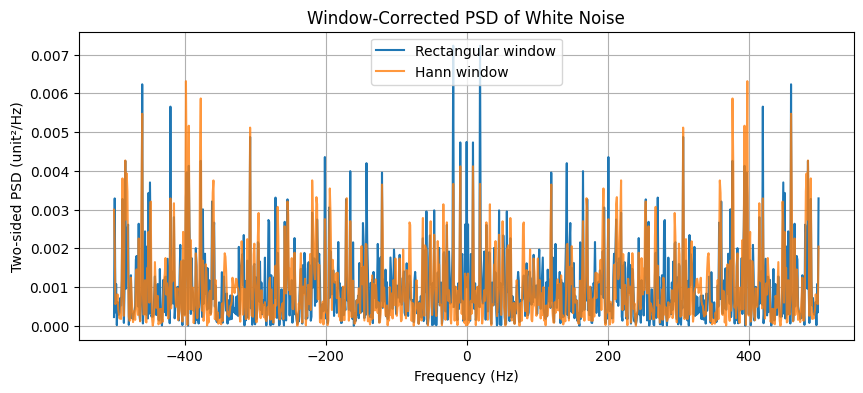

In [22]:
display(fig)

The individual PSD values differ because the windows combine nearby frequency contributions differently.

However, after window-power correction, the typical broadband PSD levels should be approximately comparable.

The Hann-window PSD is not expected to match the rectangular-window PSD bin by bin.

### 4.9 What window-power correction does not solve
Window-power correction provides the appropriate normalization for broadband power spectral density.

It does **not** imply that:
* the PSD values become smooth;
* the two windows produce identical PSD values;
* the peak height of a tone is independent of the window;
* the width of a spectral peak is independent of the window;
* spectral leakage disappears completely.

A window changes how signal power is distributed among nearby frequency bins.

> The correction $\sum_n w^2[n]$ accounts for the window’s effect on broadband mean-square level, but it does not undo the window’s spectral shape.

Detailed interpretation of tone peaks and effective noise bandwidth will be postponed.

#### Implementation note
For a windowed record, the two-sided PSD calculation can be written directly as

In [23]:
windowed_record = record * hann_window
windowed_dft = np.fft.fft(windowed_record)
windowed_psd_two_sided = np.abs(windowed_dft) ** 2 / (fs * np.sum(hann_window ** 2))

> At this stage, the normalization remains visible in the code. It should not yet be hidden inside a helper function.

#### Review questions
1. Why does applying a Hann window usually reduce the mean-square value of a finite record?
2. What quantity describes the mean-square scaling introduced by a window?
3. Why is the unwindowed denominator $Nf_s$ replaced by $f_s\sum_n w^2[n]$?
4. What does the integrated window-corrected PSD equal exactly?
5. Why is the integrated corrected PSD usually close to the ordinary mean-square value for broadband noise?
6. Does window-power correction make PSDs from different windows identical bin by bin?
7. Why should tone-peak amplitude not be interpreted using window-power correction alone?

#### Takeaway
For a windowed record,
\\[
x_w[n] = x[n]w[n],
\\]

the two-sided PSD is normalized as
\\[
\boxed{S_{xx,w}^{(2)}[k] = \frac{|X_w[k]|^2}{f_s\sum_n w^2[n]}}
\\]

The factor $\sum_n w^2[n]$ corrects for the energy of the window.

The integrated PSD satisfies
\\[
\boxed{\sum_k S_{xx,w}^{(2)}[k]\Delta f = \frac{\sum_n |x[n]|^2w^2[n]}{\sum_n w^2[n]}}
\\]

which is the window-weighted mean-square value.

For broadband noise, this value is usually close to the ordinary mean-square value of the record. Detailed window effects on tone peaks and effective bandwidth will be considered later.

## 5. One-Sided PSD for Real Signals
The PSD developed so far is a **two-sided PSD**. It contains both positive- and negative-frequency bins.

For real-valued signals, the DFT has conjugate symmetry: $X[N-k] = X^*[k]$. Therefore, $|X[N-k]|^2 = |X[k]|^2$.

The positive- and negative-frequency bins contain equal power.

In many practical applications, it is more convenient to combine the matching positive- and negative-frequency contributions into a **one-sided PSD**.

### 5.1 Why one-sided PSD values are doubled
Consider a positive-frequency bin at $f_k$ and its matching negative-frequency bin at $-f_k$.

Their two-sided PSD values are equal: $S_{xx}^{(2)}[-f_k] = S_{xx}^{(2)}[f_k]$.

If the negative-frequency bin is removed, its power must be transferred to the corresponding positive-frequency bin.

Therefore, 
\\[
S_{xx}^{(1)}[f_k] = 2S_{xx}^{(2)}[f_k].
\\]

The factor of two preserves the total mean-square power. **A one-sided PSD is therefore not created by simply discarding the negative-frequency bins**.

### 5.2 DC and Nyquist are special cases
For an even record length (N), the one-sided frequency bins are
\\[
k=0,1,\ldots,\frac{N}{2}.
\\]

The bin at $k=0$ is DC. The bin at $k=\frac{N}{2}$ is the Nyquist-frequency bin.

> DC and Nyquist do not have separate matching bins in the retained DFT array. They must therefore remain unchanged.

**At DC**, $S_{xx}^{(1)}[0] = S_{xx}^{(2)}[0]$,
The rest until (not include) the nyquist frequency ($f_{s}/2$)
\\[
S_{xx}^{(1)}[k] = 2S_{xx}^{(2)}[k],\qquad 1\le k<\frac{N}{2},
\\]

* **for an even $N$**
\\[
S_{xx}^{(1)}\left[\frac{N}{2}\right] = S_{xx}^{(2)}\left[\frac{N}{2}\right].
\\]
* **for an odd $N$** -- No data point at $N/2$.
  
Therefore:
* do not double DC;
* do not double Nyquist;
* double all remaining positive-frequency bins.

### 5.3 Constructing a one-sided PSD
Use the Hann-windowed record from the previous section.

In [24]:
record = short_noise
record_length = len(record)
hann_window = np.hanning(record_length)
windowed_record = record * hann_window

windowed_dft_one_sided = np.fft.rfft(windowed_record)
frequency_one_sided = np.fft.rfftfreq(record_length, 1 / fs)

Start with the same PSD normalization used for the two-sided PSD:

\\[
\frac{|X_w[k]|^2}{f_s\sum_n w^2[n]}.
\\]

In [25]:
window_energy = np.sum(hann_window ** 2)
psd_one_sided = np.abs(windowed_dft_one_sided) ** 2 / (fs * window_energy)

psd_one_sided[1:-1] *= 2 # Double everything apart from DC and Nyquist

fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(frequency_one_sided, psd_one_sided)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD (unit²/Hz)")
ax.set_title("One-Sided PSD of a Windowed Noise Record")
ax.grid()
plt.close(fig)

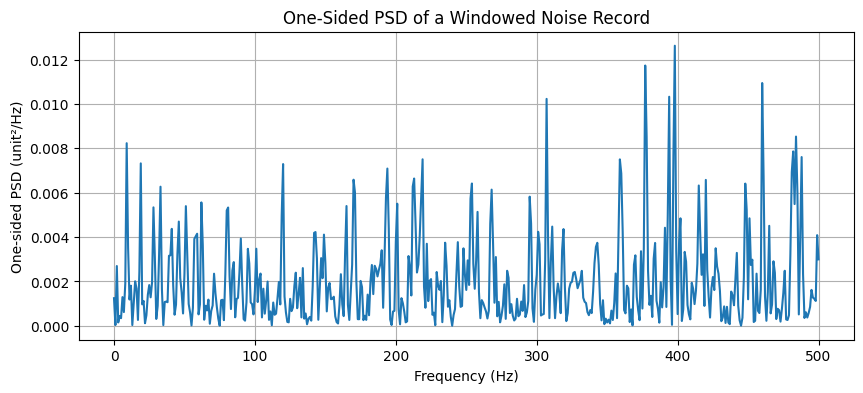

In [26]:
display(fig)

### 5.4 Verifying power preservation
The two-sided PSD from the previous section was
\\[
S_{xx,w}^{(2)}[k] = \frac{|X_w[k]|^2}{f_s\sum_n w^2[n]}.
\\]

In [27]:
#Calculate it again for comparison.
windowed_dft_two_sided = np.fft.fft(windowed_record)
psd_two_sided = np.abs(windowed_dft_two_sided) ** 2 / (fs * window_energy)

df = fs / record_length

integrated_two_sided_psd = np.sum(psd_two_sided) * df
integrated_one_sided_psd = np.sum(psd_one_sided) * df

print(f"Integrated two-sided PSD: {integrated_two_sided_psd:.12f}")
print(f"Integrated one-sided PSD: {integrated_one_sided_psd:.12f}")

Integrated two-sided PSD: 1.017596607492
Integrated one-sided PSD: 1.017596607492


Apart from floating-point roundoff, the two values should be equal.

The one-sided PSD contains fewer bins, but the retained positive-frequency bins contain the combined power from both sides of the spectrum.

### 5.5 What happens if the PSD is not doubled?

In [28]:
psd_one_sided_not_doubled = np.abs(windowed_dft_one_sided) ** 2 / (fs * window_energy)

integrated_not_doubled = np.sum(psd_one_sided_not_doubled) * df

print(f"Correct one-sided integrated PSD:   {integrated_one_sided_psd:.6f}")
print(f"Not-doubled integrated PSD:          {integrated_not_doubled:.6f}")

Correct one-sided integrated PSD:   1.017597
Not-doubled integrated PSD:          0.510919


For a signal with little power at DC and Nyquist, the incorrectly scaled result will be approximately half of the correct value.

This occurs because the negative-frequency power has been discarded rather than transferred to the positive-frequency bins.

### 5.6 Why DC and Nyquist are not doubled
* The DC bin represents the constant or zero-frequency component of the signal. It does not form a separate positive-negative frequency pair.
* There is only one independent Nyquist bin, so it must not be doubled.


### 5.7 General implementation rule
A general implementation can therefore test whether $N$ is even or odd.
```python
if record_length % 2 == 0: 
    # This is for an even N
    psd_one_sided[1:-1] *= 2
else:
    # This of for an odd N
    psd_one_sided[1:] *= 2
```

### 5.8 One-sided PSD normalization formula
1. For a real-valued, windowed record,
\\[
x_w[n] = x[n]w[n],
\\]
2. calculate
\\[
X_w[k] = \operatorname{rFFT}{x_w[n]}.
\\]
3. Calculate $S_{xx}[k]$,
\\[
S_{xx}[k] = \frac{|X_w[k]|^2}{f_s\sum_n w^2[n]}.
\\]
4. Then take only the positive half and:
* keep DC unchanged;
* keep Nyquist unchanged when (N) is even;
* double all other retained frequency bins.

The resulting is the one-sided PSD $S_{xx}^{(1)}$ which satisfies
\\[
\boxed{\sum_{k=0}^{N/2}S_{xx}^{(1)}[k]\Delta f = \sum_{k=0}^{N-1} S_{xx}^{(2)}[k]\Delta f}
\\]

Both representations contain the same mean square signal (average power).

#### Terminology note
A one-sided PSD is appropriate for real-valued signals when only nonnegative frequencies need to be displayed.

A two-sided PSD is still useful when:
* negative frequencies have a meaningful interpretation;
* the signal is complex-valued;
* frequency shifting or complex baseband processing is involved.

> For the real-valued signals used in this notebook, the one-sided PSD will be used in the remaining sections.

#### Review questions
1. Why do positive- and negative-frequency bins contain equal power for a real-valued signal?
2. Why must most positive-frequency PSD bins be doubled?
3. Why is the DC bin not doubled?
4. Why is the Nyquist bin not doubled when $N$ is even?
5. What happens to the integrated PSD if the negative-frequency bins are removed without doubling the positive-frequency bins?
6. Does an odd-length record contain a Nyquist bin?
7. Do one-sided and two-sided PSDs represent different total signal powers?

#### Takeaway
For a real-valued signal, matching positive- and negative-frequency bins contain equal power.
A one-sided PSD combines these contributions:
\\[
S_{xx}^{(1)}[k] = 2S_{xx}^{(2)}[k]
\\]

for the positive-frequency bins that have separate negative-frequency partners. **DC is not doubled**, and **the Nyquist bin** is not doubled when (N) is even.

With correct doubling,
\\[
\boxed{\text{integrated one-sided PSD} = \text{integrated two-sided PSD}}
\\]

The two representations contain the same average power.

## 6. Interpreting PSD: Noise, Tones, and Decibels
A correctly normalized PSD allows spectra obtained with different record lengths to be compared on the same power-per-hertz scale.
However, broadband noise and deterministic tones do not appear in the same way:
* broadband noise spreads its power over a wide frequency range;
* a tone concentrates its power near one frequency.

This section examines how both components should be interpreted.

### 6.1 A tone in broadband noise
Create two records containing:
* a sinusoid at $125\ \text{Hz}$;
* zero-mean white noise;
* the same sampling frequency;
* different record lengths.

In [29]:
# Parameters
fs = 1000
tone_frequency = 125
tone_amplitude = 1
noise_standard_deviation = 0.2
short_length = 1000
long_length = 4000

# Signal generations
random_generator = np.random.default_rng(20)
long_noise = random_generator.normal(0, noise_standard_deviation, long_length)
short_noise = long_noise[:short_length]
short_time = np.arange(short_length) / fs
long_time = np.arange(long_length) / fs
short_signal = tone_amplitude * np.sin(2 * np.pi * tone_frequency * short_time) + short_noise
long_signal = tone_amplitude * np.sin(2 * np.pi * tone_frequency * long_time) + long_noise

In [30]:
# The two records describe the same type of signal, but their frequency-bin spacings differ.

short_df = fs / short_length
long_df = fs / long_length

print(f"Short-record frequency spacing: {short_df:.2f} Hz")
print(f"Long-record frequency spacing:  {long_df:.2f} Hz")

Short-record frequency spacing: 1.00 Hz
Long-record frequency spacing:  0.25 Hz


### 6.2 Calculate the one-sided PSDs

In [31]:
#Apply Hann windows to both records.
short_window = np.hanning(short_length)
long_window = np.hanning(long_length)

short_windowed_signal = short_signal * short_window
long_windowed_signal = long_signal * long_window

#Calculate the one-sided DFTs.
short_dft = np.fft.rfft(short_windowed_signal)
long_dft = np.fft.rfft(long_windowed_signal)

In [32]:
#Calculate the nonnegative-frequency PSD values.
short_window_energy = np.sum(short_window ** 2)
long_window_energy = np.sum(long_window ** 2)

short_psd_nonnegative = np.abs(short_dft) ** 2 / (fs * short_window_energy)
long_psd_nonnegative = np.abs(long_dft) ** 2 / (fs * long_window_energy)

#Copy the arrays and apply one-sided doubling.
short_psd = short_psd_nonnegative.copy()
long_psd = long_psd_nonnegative.copy()

short_psd[1:-1] *= 2
long_psd[1:-1] *= 2

In [42]:
#Create the frequency axes.
short_frequency = np.fft.rfftfreq(short_length, 1 / fs)
long_frequency = np.fft.rfftfreq(long_length, 1 / fs)

fig, ax = plt.subplots(2,1,figsize=(10,4),sharex=True)
ax[0].plot(short_frequency, 10*np.log10(short_psd), label=f"N = {short_length}")
ax[1].plot(long_frequency, 10*np.log10(long_psd), label=f"N = {long_length}", alpha=0.8)
ax[1].set_xlabel("Frequency (Hz)")
ax[0].set_title("PSD of a Tone in Broadband Noise")
for i in range(2):
    ax[i].grid()
    ax[i].legend()
    ax[i].set_ylabel("One-sided PSD (unit²/Hz)")
plt.close(fig)

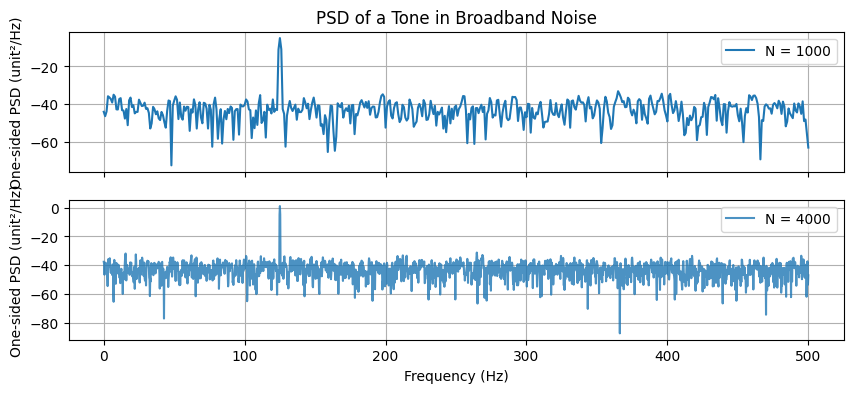

In [43]:
display(fig)

The tone produces a large narrow peak near $125\ \text{Hz}$, while the noise produces irregular values spread across the frequency range.

Because the tone peak is much larger than the noise PSD, the linear plot may make the noise difficult to see. A decibel plot is used instead.

### 6.3 Interpreting the broadband noise level
The longer record has narrower frequency bins. Therefore, its power per bin is smaller.

After dividing by the bin width, however, the broadband PSD levels should be approximately comparable.

In [34]:
# Select a frequency band that does not include the tone.
noise_band_minimum = 250
noise_band_maximum = 450

short_noise_band = (short_frequency >= noise_band_minimum) & (short_frequency <= noise_band_maximum)
long_noise_band = (long_frequency >= noise_band_minimum) & (long_frequency <= noise_band_maximum)

#Calculate the mean PSD in this band.
short_mean_noise_psd = np.mean(short_psd[short_noise_band])
long_mean_noise_psd = np.mean(long_psd[long_noise_band])

print(f"Short-record mean noise PSD: {short_mean_noise_psd:.6e} unit²/Hz")
print(f"Long-record mean noise PSD:  {long_mean_noise_psd:.6e} unit²/Hz")

Short-record mean noise PSD: 8.750290e-05 unit²/Hz
Long-record mean noise PSD:  7.665161e-05 unit²/Hz


The values will not be identical because the records are finite and random. Nevertheless, they should be on approximately the same power-per-hertz scale.

For zero-mean white noise with variance $\sigma^2$, the theoretical one-sided PSD level is
\\[
S_0 = \frac{2\sigma^2}{f_s}.
\\]

For this noise, $\sigma=0.2$, so $\sigma^2=0.04$.

In [35]:
theoretical_noise_psd = 2 * noise_standard_deviation ** 2 / fs

print(f"Theoretical one-sided noise PSD: {theoretical_noise_psd:.6e} unit²/Hz")

Theoretical one-sided noise PSD: 8.000000e-05 unit²/Hz


One finite-record PSD does not follow this level exactly at every bin. Its values fluctuate around the theoretical broadband level.

### 6.4 Interpreting the tone peak
The tone has a fixed mean-square value: 
\\[
P_{\text{tone}} = \frac{A^2}{2}.
\\]

For (A=1),
\\[
P_{\text{tone}} = 0.5.
\\]

Unlike broadband noise, this power is concentrated near one frequency.

The longer record has finer frequency resolution, so the tone power is concentrated into a narrower frequency region. Its peak PSD can therefore be higher even though the tone itself has not become more powerful.

In [36]:
#Find the largest PSD value near the tone.
tone_search_minimum = 115
tone_search_maximum = 135

short_tone_search = (short_frequency >= tone_search_minimum) & (short_frequency <= tone_search_maximum)
long_tone_search = (long_frequency >= tone_search_minimum) & (long_frequency <= tone_search_maximum)

short_tone_peak_psd = np.max(short_psd[short_tone_search])
long_tone_peak_psd = np.max(long_psd[long_tone_search])

print(f"Short-record tone peak PSD: {short_tone_peak_psd:.6f} unit²/Hz")
print(f"Long-record tone peak PSD:  {long_tone_peak_psd:.6f} unit²/Hz")

Short-record tone peak PSD: 0.315907 unit²/Hz
Long-record tone peak PSD:  1.301683 unit²/Hz


> The peak PSD values are different because PSD describes power **per hertz**.

A narrower spectral peak can have a greater height while containing approximately the same total power.

Therefore:

> The height of a tone peak should not be interpreted as the tone power by itself.

### 6.5 Tone power is represented by area
To estimate the power associated with the tone, integrate the PSD over a frequency band surrounding it.

In [37]:
# Use the interval from (120\ \text{Hz}) to (130\ \text{Hz}).
tone_band_minimum = 120
tone_band_maximum = 130

short_tone_band = (short_frequency >= tone_band_minimum) & (short_frequency <= tone_band_maximum)
long_tone_band = (long_frequency >= tone_band_minimum) & (long_frequency <= tone_band_maximum)

# Calculate the total PSD area in this band.
short_tone_band_power = np.sum(short_psd[short_tone_band]) * short_df
long_tone_band_power = np.sum(long_psd[long_tone_band]) * long_df

print(f"Short-record power in tone band: {short_tone_band_power:.6f}")
print(f"Long-record power in tone band:  {long_tone_band_power:.6f}")
print(f"Ideal tone mean-square power:     {tone_amplitude ** 2 / 2:.6f}")

Short-record power in tone band: 0.475129
Long-record power in tone band:  0.488714
Ideal tone mean-square power:     0.500000


The integrated values include both:
* the tone power;
* a small amount of noise power in the selected band.

They should be much more comparable than the peak PSD values.

This illustrates an important distinction:
* for broadband noise, **the PSD level** itself is meaningful;
* for a tone, **the area around the spectral peak** is more closely related to its power.

Detailed tone-amplitude estimation and window-bandwidth correction are beyond the scope of this notebook.

### 6.6 What can and cannot be compared directly?
A correctly normalized PSD supports the following comparisons:
* broadband noise levels from records with different lengths;
* power density in selected frequency ranges;
* integrated power over equal frequency bands;
* relative levels expressed in decibels.

Care is required when comparing:
* individual random-noise bins;
* tone peak heights obtained with different record lengths;
* tone peaks obtained with different windows;
* spectra using different one-sided or two-sided conventions;
* decibel values that use different references.

Normalization makes the units and scale meaningful. It does not make all spectral features independent of record length or window choice.

#### Review questions
1. Why are broadband PSD levels approximately comparable when record lengths differ?
2. Why can a longer record produce a higher tone peak in units of power per hertz?
3. Which is more closely related to tone power: peak PSD height or area around the tone?
4. Why does one finite white-noise PSD remain irregular?
5. Why is $10\log_{10}$ used to convert PSD to decibels?
6. If a signal amplitude is doubled, by what factor does its PSD increase?
7. What is the corresponding PSD-level increase in decibels?
8. Why must the PSD reference be stated when reporting a decibel value?

#### Takeaway
Broadband noise and tones must be interpreted differently.

**For broadband noise**:
> The PSD level describes mean-square power per hertz.

**For a tone**:
> The power is represented by the area around its spectral peak, not by the peak height alone.

A longer record can produce a narrower and taller tone peak without changing the tone power.

PSD is a power quantity, so its decibel conversion is
\\[
\boxed{S_{\mathrm{dB}} = 10\log_{10}\left(\frac{S_{xx}}{S_{\mathrm{ref}}}\right)}
\\]

Correct normalization makes spectra comparable, but record length and window choice still affect the appearance of individual spectral components.

## 7. Complete PSD Workflow and Summary
The previous sections developed the PSD calculation one step at a time.

This final section combines the complete workflow for a real-valued, windowed signal.

No new normalization is introduced here.

### 7.1 Complete calculation workflow
For a sampled record $x[n]$:
1. choose a window $w[n]$;
2. multiply the record by the window;
3. calculate the nonnegative-frequency DFT using `rfft()`;
4. **normalize by the sampling frequency and window energy**;
5. apply one-sided doubling;
6. create the frequency axis;
7. verify the result by integrating the PSD.

In [38]:
# Use the long tone-plus-noise record from the previous section.
record = long_signal
record_length = len(record)

window = np.hanning(record_length)
windowed_record = record * window

dft_values = np.fft.rfft(windowed_record)
frequency = np.fft.rfftfreq(record_length, 1 / fs)

# Calculate the PSD values before one-sided doubling.
window_energy = np.sum(window ** 2)
psd = np.abs(dft_values) ** 2 / (fs * window_energy)

if record_length % 2 == 0:
    psd[1:-1] *= 2
else:
    psd[1:] *= 2
# The array psd is now the one-sided PSD estimate (V^{2}/Hz).

### 7.2 Plot the PSD
Plot the PSD using a logarithmic vertical scale so that both the tone and broadband noise are visible.

In [48]:
fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(frequency, 10*np.log10(psd))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD (dB re. 1 unit²/Hz)")
ax.set_title("One-Sided PSD Estimate")
ax.grid()
plt.close(fig)

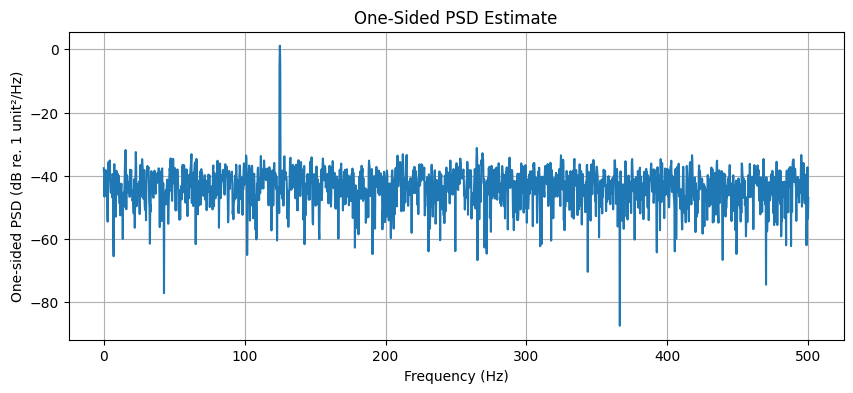

In [49]:
display(fig)

The plot should show:
* a narrow peak near the tone frequency;
* irregular broadband noise across the frequency range;
* PSD values expressed per hertz.

### 7.3 Verify the integrated PSD

In [50]:
df = fs / record_length
integrated_psd = np.sum(psd) * df
weighted_mean_square = np.sum(record ** 2 * window ** 2) / np.sum(window ** 2)

print(f"Integrated PSD:              {integrated_psd:.12f}")
print(f"Window-weighted mean square: {weighted_mean_square:.12f}")

Integrated PSD:              0.526932208635
Window-weighted mean square: 0.526932208635


Apart from floating-point roundoff, the two values should be equal.

This check is useful because it verifies the complete normalization:
* DFT scaling;
* frequency-density scaling;
* window-energy correction;
* one-sided doubling.

### 7.4 Interpret selected frequency bands
The power contained in a frequency interval is estimated by
\\[
P_{\text{band}} \approx \sum_{k\in\text{band}} S_{xx}[k]\Delta f.
\\]

For example, calculate the power in the tone band and selected noise band.

In [41]:
tone_band = (frequency >= tone_band_minimum) & (frequency <= tone_band_maximum)
tone_band_power = np.sum(psd[tone_band]) * df
print(f"Power in the tone band: {tone_band_power:.6f}")

noise_band = (frequency >= noise_band_minimum) & (frequency <= noise_band_maximum)
noise_band_power = np.sum(psd[noise_band]) * df
print(f"Power in the noise band: {noise_band_power:.6f}")

Power in the tone band: 0.488714
Power in the noise band: 0.015349


> The PSD level describes power per hertz.

> The PSD area over a selected bandwidth describes the average power contained in that interval.

### 7.5 What the normalization factors do
The complete one-sided PSD calculation contains several normalization steps.

#### DFT normalization
> For NumPy’s DFT convention, Parseval’s theorem determines the required dependence on record length.

#### Frequency normalization
> Dividing by frequency-bin width changes power per bin into power per hertz.

#### Window-energy normalization
> Dividing by $\sum_n w^2[n]$ compensates for the average power scaling introduced by the window.

#### One-sided doubling
> Doubling the appropriate positive-frequency bins transfers the matching negative-frequency power into the one-sided representation.

Each factor has a separate purpose.

### 7.6 Main distinctions
The following quantities must not be confused.
| Quantity                   | Meaning                                      |
| -------------------------- | -------------------------------------------- |
| $X[k]$                     | DFT coefficient                              |
| $|X[k]|$                   | DFT magnitude                                |
| $|X[k]|^{2}$               | Squared DFT magnitude                        |
| $P_{\text{bin}}[k]$        | Mean-square power represented by one DFT bin |
| $S_{xx}[k]$                | Mean-square power per hertz                  |
| $\sum_k S_{xx}[k]\Delta f$ | Mean-square power over a frequency range     |

A PSD is not simply a squared DFT magnitude. **Its normalization gives it a physical interpretation and units per hertz**.

### 7.7 Main interpretation rules
**For broadband noise**:
* power is distributed over many frequency bins;
* PSD level is approximately comparable across record lengths;
* one finite-record PSD remains irregular.

**For a tone**:
* power is concentrated near one frequency;
* peak PSD height depends on record length and window;
* the area around the peak is more closely related to tone power.

**For any selected frequency band**:
\\[
\boxed{\text{band power} \approx \sum_{k\in\text{band}}S_{xx}[k]\Delta f}
\\]

### 7.8 What PSD normalization does not solve
Correct normalization makes PSD values meaningful and comparable.

But it does not make a finite-record PSD estimate stable. Different noise realizations still produce different PSD values at individual frequency bins.

The next topic will examine how averaging can reduce this spectral variability.
Topics postponed to the next notebook include:

* averaging multiple PSD estimates;
* dividing a record into segments;
* Bartlett’s method;
* Welch’s method;
* overlap;
* estimator variability.

#### Final review questions
1. Why is power per DFT bin divided by $\Delta f$?
2. What are the units of PSD if the signal is measured in volts?
3. Why is window-energy normalization required?
4. Which one-sided PSD bins should not be doubled?
5. What does the area under the complete PSD represent?
6. What does the area under the PSD over a limited frequency interval represent?
7. Why can two records have similar broadband PSD levels but different tone peak heights?
8. Does correct normalization remove the random variability of a finite-record PSD?

#### Summary
Power per DFT bin depends on frequency resolution. Dividing by the bin width produces power spectral density:
\\[
S_{xx}[k] = \frac{P_{\text{bin}}[k]}{\Delta f}.
\\]

For a real-valued, windowed record, the PSD calculation must include:
* DFT normalization;
* division by sampling frequency;
* window-energy correction;
* one-sided doubling.

A correctly normalized PSD satisfies
\\[
\boxed{\text{PSD area} = \text{mean-square power}}
\\]
* Broadband noise is interpreted mainly through its PSD level.
* Tonal components are interpreted mainly through the area around their spectral peaks.

PSD normalization provides the correct scale and units. Averaging, introduced next, will provide a more stable spectral estimate.